## Compare ATAC-seq and PRO-seq responses

1. Directly see if early response and such (UpSet)
2. 

In [7]:
library(ComplexHeatmap)
library(clusterProfiler)
library(org.Hs.eg.db)
library(data.table)
library(stringr)

Warning message:
"package 'stringr' was built under R version 4.4.1"


In [1]:
get_mu_list <- function(sig_list) {
	chrom_split <- str_split_fixed(sig_list, ":", 2)
	bp_split <- str_split_fixed(chrom_split[,2], "-", 2)
	mu_list <- as.numeric((as.numeric(bp_split[,1]) + as.numeric(bp_split[,2]))/2)
	final_list = paste0(chrom_split[,1], ":", mu_list)
return(final_list)
}

get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
	early = union(early_rise, early_fall)
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
	plat = union(plat_rise, plat_fall)
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))

	late = union(late_rise, late_fall)
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall, "Early"=early, "Plat"=plat, "Late"=late)
    return(time_sig)
    }

## Read in results

In [29]:
UPM_pro_30 <- fread("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt")
UPM_pro_120 <- fread("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt")
UPM_pro_30[1:2,]
UPM_pro_30$Enhancer <- get_mu_list(UPM_pro_30$V1)
colnames(UPM_pro_30) <- c("V1", "baseMean", "PRO30", "lfcSE", "stat", "pvalue", "PRO30_padj", "Enhancer")
UPM_pro_120$Enhancer <- get_mu_list(UPM_pro_120$V1)
colnames(UPM_pro_120) <- c("V1", "baseMean", "PRO120", "lfcSE", "stat", "pvalue", "PRO120_padj", "Enhancer")

WSP_pro_30 <- fread("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt")
WSP_pro_120 <- fread("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt")
WSP_pro_30$Enhancer <- get_mu_list(WSP_pro_30$V1)
colnames(WSP_pro_30) <- c("V1", "baseMean", "PRO30", "lfcSE", "stat", "pvalue", "PRO30_padj", "Enhancer")
WSP_pro_120$Enhancer <- get_mu_list(WSP_pro_120$V1)
colnames(WSP_pro_120) <- c("V1", "baseMean", "PRO120", "lfcSE", "stat", "pvalue", "PRO120_padj", "Enhancer")

UPM_atac_30 <- fread("../results/DESeq2/res_ATAC_UPM30_vs_Veh_par_rat_Wd.txt")
UPM_atac_120 <- fread("../results/DESeq2/res_ATAC_UPM120_vs_Veh_par_rat_Wd.txt")
colnames(UPM_atac_30) <- c("Enhancer", "baseMean", "ATAC30", "lfcSE", "stat", "pvalue", "ATAC30_padj")
colnames(UPM_atac_120) <- c("Enhancer", "baseMean", "ATAC120", "lfcSE", "stat", "pvalue", "ATAC120_padj")

WSP_atac_30 <- fread("../results/DESeq2/res_ATAC_WSP30_vs_Veh_NEC_par_rat_Wd.txt")
WSP_atac_120 <- fread("../results/DESeq2/res_ATAC_WSP120_vs_Veh_NEC_par_rat_Wd.txt")
colnames(WSP_atac_30) <- c("Enhancer", "baseMean", "ATAC30", "lfcSE", "stat", "pvalue", "ATAC30_padj")
colnames(WSP_atac_120) <- c("Enhancer", "baseMean", "ATAC120", "lfcSE", "stat", "pvalue", "ATAC120_padj")

Warning message in fread("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt"):
"Se detectaron 6 nombres de columna, pero los datos tienen 7 columnas (p.ej. un archivo no v'alido). Se agrega un nombre de columna por defecto para la primera columna, asumiendo que son nombres de fila o un 'indice. Si cree que esto no es correcto, utilice setnames() luego de la carga, o modifique la instrucci'on que cre'o el archivo para crear un archivo v'alido."
Warning message in fread("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt"):
"Se detectaron 6 nombres de columna, pero los datos tienen 7 columnas (p.ej. un archivo no v'alido). Se agrega un nombre de columna por defecto para la primera columna, asumiendo que son nombres de fila o un 'indice. Si cree que esto no es correcto, utilice setnames() luego de la carga, o modifique la instrucci'on que cre'o el archivo para crear un archivo v'alido."


V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr5:399569-400251,1299.3193,3.977447,0.1647303,24.14521,8.384696e-129,3.740329e-124
chr3:107524566-107525130,752.7875,-3.160091,0.1878904,-16.81880,1.777115e-63,3.963766e-59


Warning message in fread("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt"):
"Se detectaron 6 nombres de columna, pero los datos tienen 7 columnas (p.ej. un archivo no v'alido). Se agrega un nombre de columna por defecto para la primera columna, asumiendo que son nombres de fila o un 'indice. Si cree que esto no es correcto, utilice setnames() luego de la carga, o modifique la instrucci'on que cre'o el archivo para crear un archivo v'alido."
Warning message in fread("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt"):
"Se detectaron 6 nombres de columna, pero los datos tienen 7 columnas (p.ej. un archivo no v'alido). Se agrega un nombre de columna por defecto para la primera columna, asumiendo que son nombres de fila o un 'indice. Si cree que esto no es correcto, utilice setnames() luego de la carga, o modifique la instrucci'on que cre'o el archivo para crear un archivo v'alido."
Warning message in fread("../results/DESeq2/res_ATAC_UPM30_vs_Veh_par_rat_W

In [30]:
UPM_df <- merge(UPM_pro_30[,c("Enhancer", "PRO30", "PRO30_padj")], UPM_pro_120[,c("Enhancer", "PRO120", "PRO120_padj")], by="Enhancer", all=TRUE)
UPM_df <- merge(UPM_df, UPM_atac_30[,c("Enhancer", "ATAC30", "ATAC30_padj")], by="Enhancer", all=TRUE)
UPM_df <- merge(UPM_df, UPM_atac_120[,c("Enhancer", "ATAC120", "ATAC120_padj")], by="Enhancer", all=TRUE)

WSP_df <- merge(WSP_pro_30[,c("Enhancer", "PRO30", "PRO30_padj")], WSP_pro_120[,c("Enhancer", "PRO120", "PRO120_padj")], by="Enhancer", all=TRUE)
WSP_df <- merge(WSP_df, WSP_atac_30[,c("Enhancer", "ATAC30", "ATAC30_padj")], by="Enhancer", all=TRUE)
WSP_df <- merge(WSP_df, WSP_atac_120[,c("Enhancer", "ATAC120", "ATAC120_padj")], by="Enhancer", all=TRUE)

In [8]:
# enhancers and types
## PRO-seq
UPM_sig_nontss <- readRDS("../results/DESeq2/UPM_signontss_DESeq2_GeneHK_p001.rds")
WSP_sig_nontss <- readRDS("../results/DESeq2/WSP_signontss_DESeq2_GeneHK_p001.rds")

lapply(UPM_sig_nontss, length)
lapply(WSP_sig_nontss, length)

# get the cleaned versions
for (timing in names(UPM_sig_nontss)) {
	UPM_sig_nontss[[timing]] = get_mu_list(UPM_sig_nontss[[timing]])
	WSP_sig_nontss[[timing]] = get_mu_list(WSP_sig_nontss[[timing]])
}


## ATAC-seq
UPM_sig_atac <- readRDS("../results/DESeq2/UPM_signontss_NEC_ATAC_DESeq2.rds")
WSP_sig_atac <- readRDS("../results/DESeq2/WSP_NEC_signontss_ATAC_DESeq2.rds")

lapply(UPM_sig_atac, length)
lapply(WSP_sig_atac, length)



$P120_vs_Veh_up
[1] 261

$`30_vs_Veh_up`
[1] 0

$P120_vs_P30_up
[1] 1361

$P120_vs_Veh_down
[1] 12929

$`30_vs_Veh_down`
[1] 0

$P120_vs_P30_down
[1] 16443

$P30_vs_Veh_up
[1] 5691

$P30_vs_Veh_down
[1] 4091

$P120_vs_Veh_up
[1] 408

$`30_vs_Veh_up`
[1] 0

$P120_vs_P30_up
[1] 2512

$P120_vs_Veh_down
[1] 4159

$`30_vs_Veh_down`
[1] 0

$P120_vs_P30_down
[1] 5305

$P30_vs_Veh_up
[1] 3194

$P30_vs_Veh_down
[1] 3872

$P120_vs_Veh_up
[1] 1999

$P30_vs_Veh_up
[1] 2509

$P120_vs_P30_up
[1] 498

$P120_vs_Veh_down
[1] 480

$P30_vs_Veh_down
[1] 564

$P120_vs_P30_down
[1] 614

$P120_vs_Veh_up
[1] 3045

$P30_vs_Veh_up
[1] 3355

$P120_vs_P30_up
[1] 1644

$P120_vs_Veh_down
[1] 2302

$P30_vs_Veh_down
[1] 775

$P120_vs_P30_down
[1] 2722

In [10]:
# Get timing
UPM_time_sig_nontss = get_timing_sig(UPM_sig_nontss)
WSP_time_sig_nontss = get_timing_sig(WSP_sig_nontss)
UPM_time_sig_atac = get_timing_sig(UPM_sig_atac)
WSP_time_sig_atac = get_timing_sig(WSP_sig_atac)
names(WSP_time_sig_atac)

[1] "ER"    "EF"    "EPR"   "EPF"   "LR"    "LF"    "Early" "Plat"  "Late"

## UpSet Plots of different responses

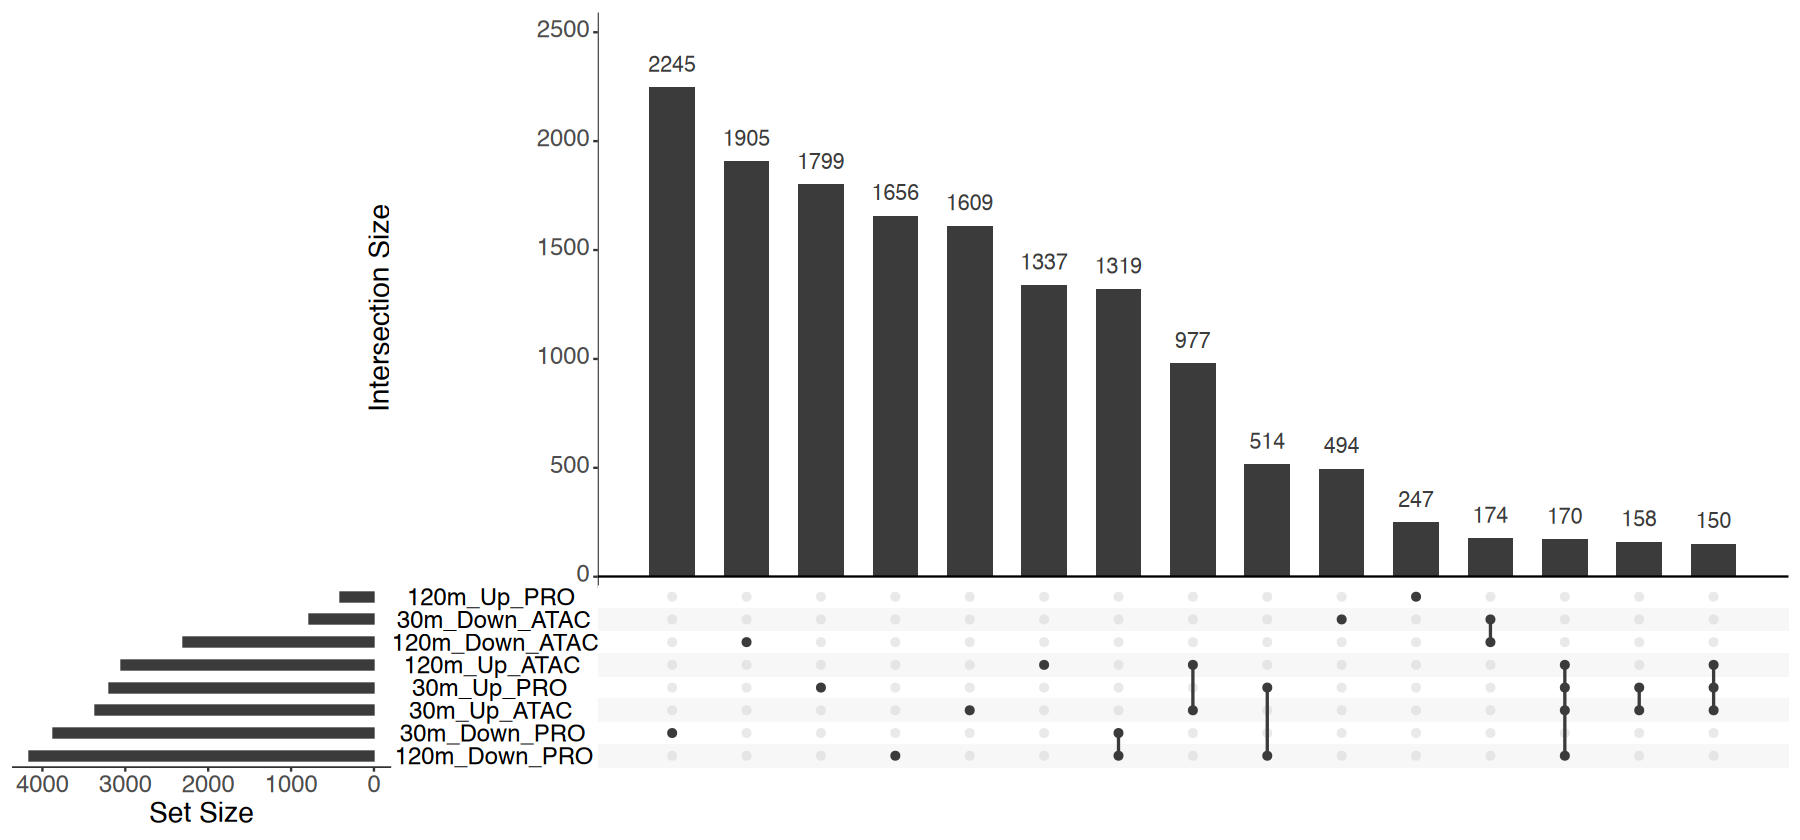

In [ ]:
WSP_time <- list("30m_Up_ATAC"=WSP_sig_atac$P30_vs_Veh_up, "30m_Down_ATAC"=WSP_sig_atac$P30_vs_Veh_down, 
"120m_Up_ATAC"=WSP_sig_atac$P120_vs_Veh_up, "120m_Down_ATAC"=WSP_sig_atac$P120_vs_Veh_down, 
"30m_Up_PRO"=WSP_sig_nontss$P30_vs_Veh_up, "30m_Down_PRO"=WSP_sig_nontss$P30_vs_Veh_down, 
"120m_Up_PRO"=WSP_sig_nontss$P120_vs_Veh_up, "120m_Down_PRO"=WSP_sig_nontss$P120_vs_Veh_down)
library(UpSetR)
options(repr.plot.width=15)
upset(fromList(WSP_time), text.scale=2, nsets=8, order.by="freq", keep.order=TRUE, nintersects=15)

1319 PRO down
977 ATAC up
514 Early rise (then down) PRO
174 ATAC down
170 ATAC up and Early rise (then down) PRO
158 30min Up
150 ATAC up and PRO 30 up

Overally, the greatest simarilites are with those rising with the 120min down in ATAC [which makes sense given those are the biggest numbers]

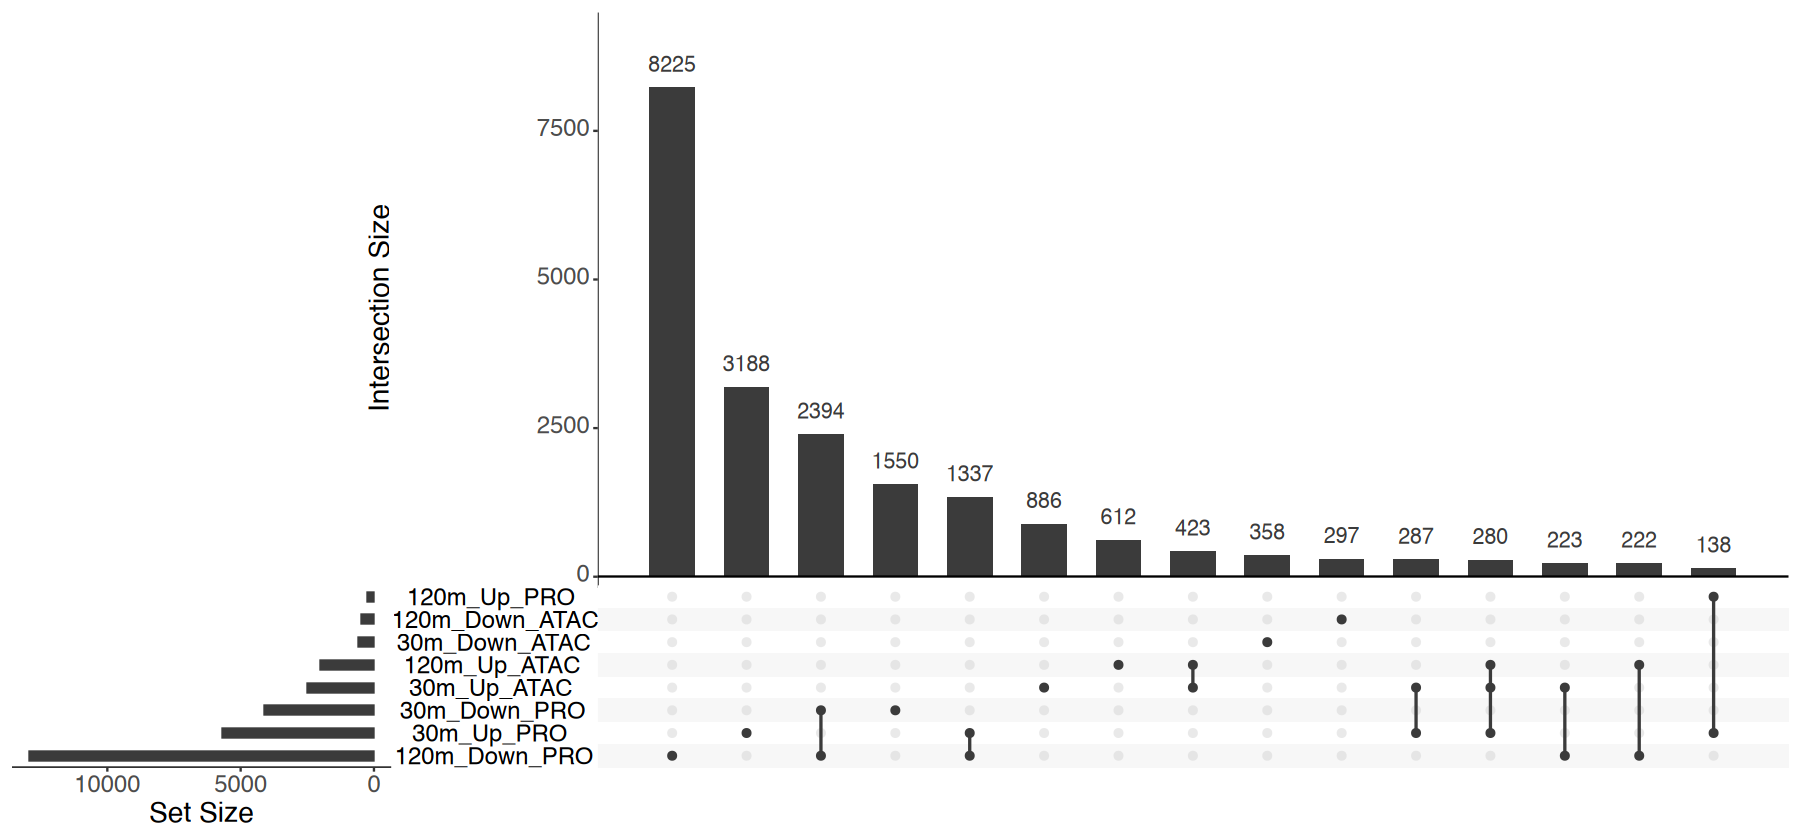

In [ ]:
UPM_time <- list("30m_Up_ATAC"=UPM_sig_atac$P30_vs_Veh_up, "30m_Down_ATAC"=UPM_sig_atac$P30_vs_Veh_down, 
"120m_Up_ATAC"=UPM_sig_atac$P120_vs_Veh_up, "120m_Down_ATAC"=UPM_sig_atac$P120_vs_Veh_down, 
"30m_Up_PRO"=UPM_sig_nontss$P30_vs_Veh_up, "30m_Down_PRO"=UPM_sig_nontss$P30_vs_Veh_down, 
"120m_Up_PRO"=UPM_sig_nontss$P120_vs_Veh_up, "120m_Down_PRO"=UPM_sig_nontss$P120_vs_Veh_down)
options(repr.plot.width=15)
upset(fromList(UPM_time), text.scale=2, nsets=8, order.by="freq", keep.order=TRUE, nintersects=15)


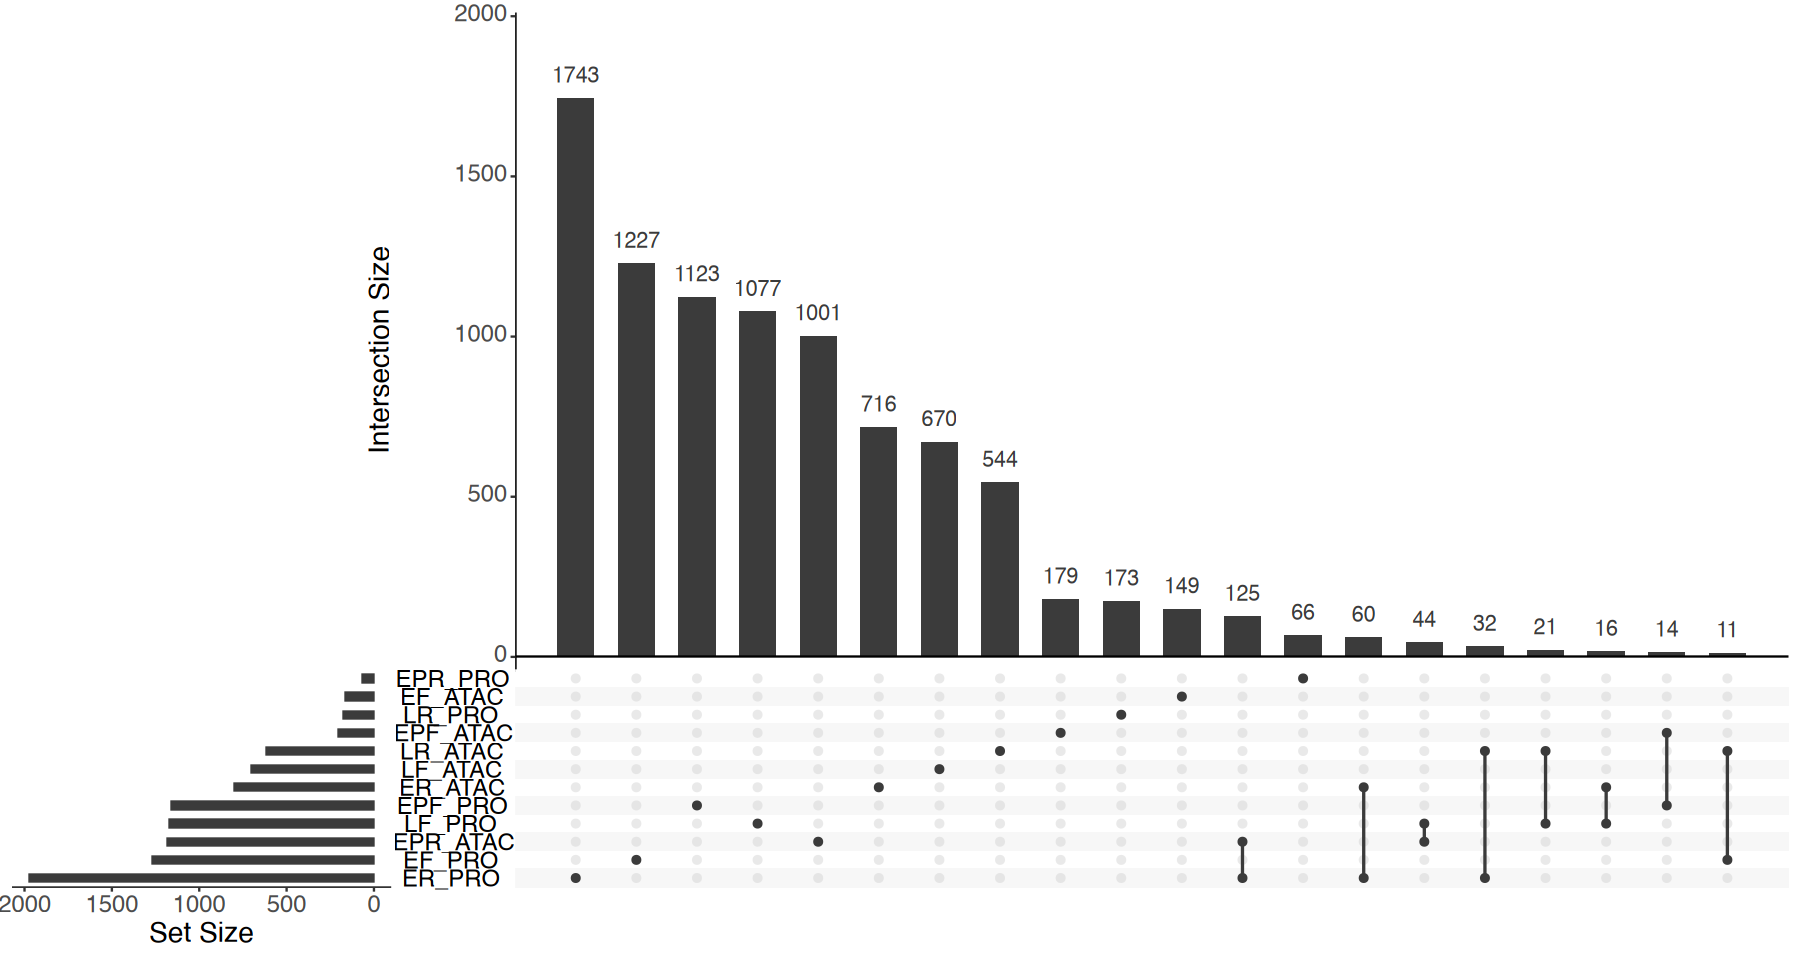

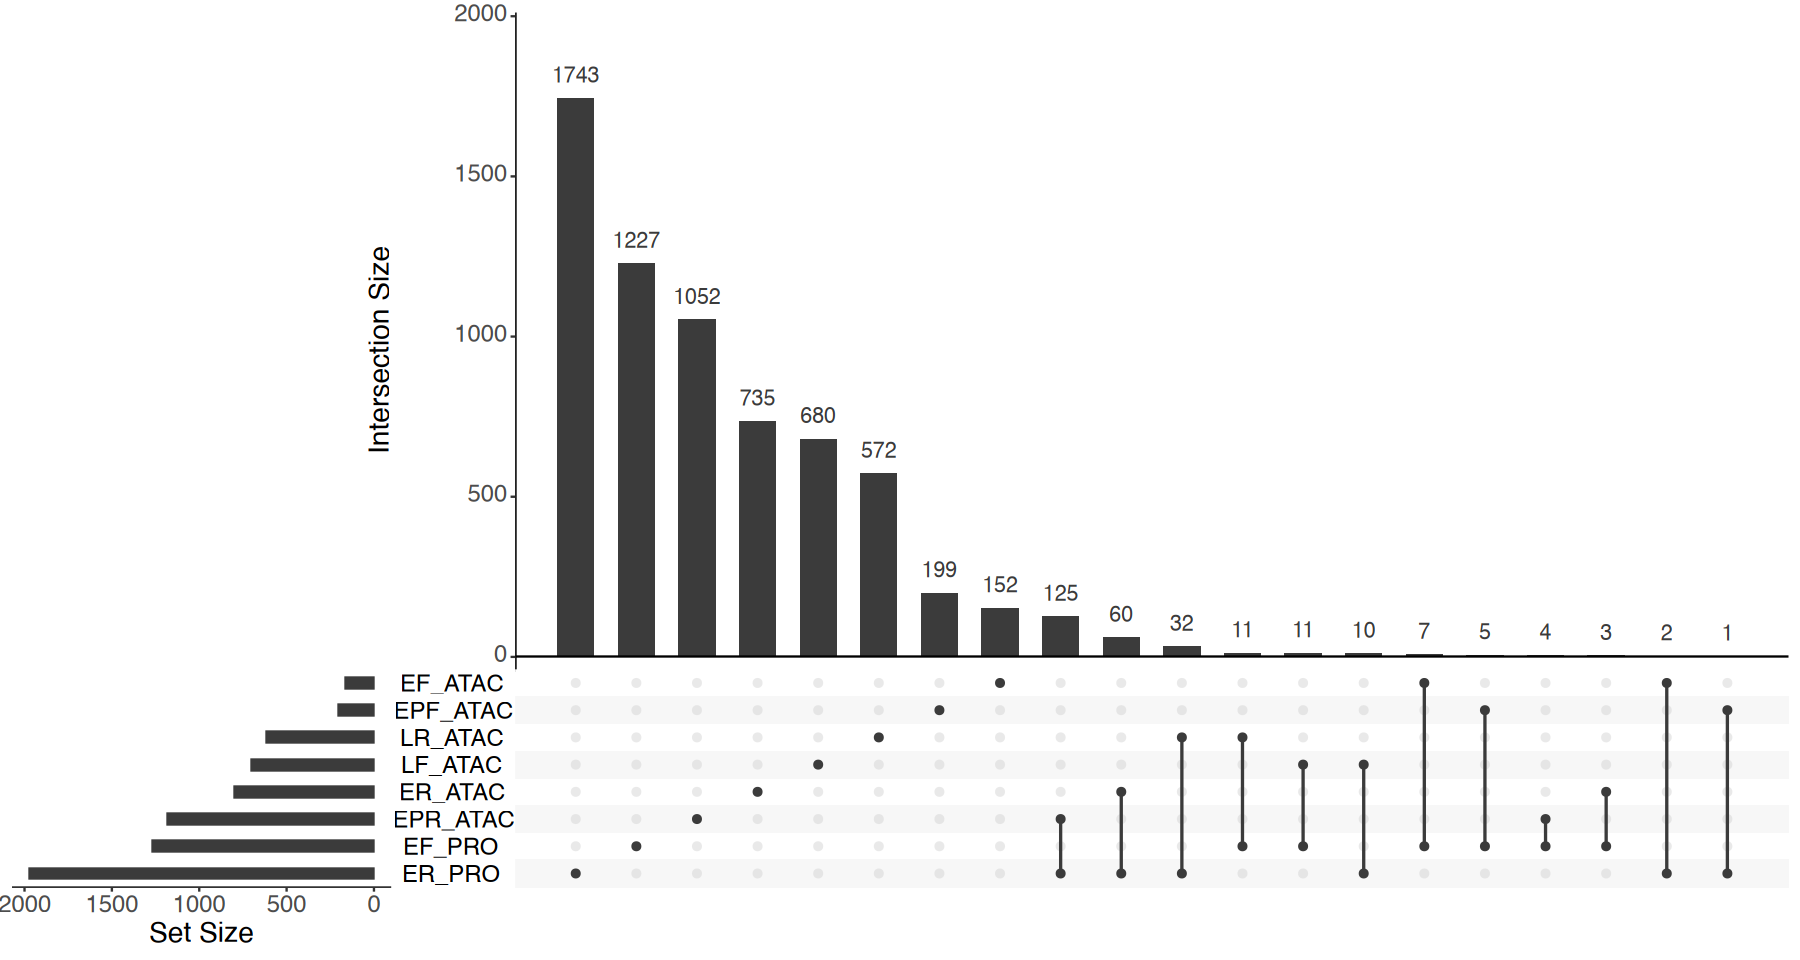

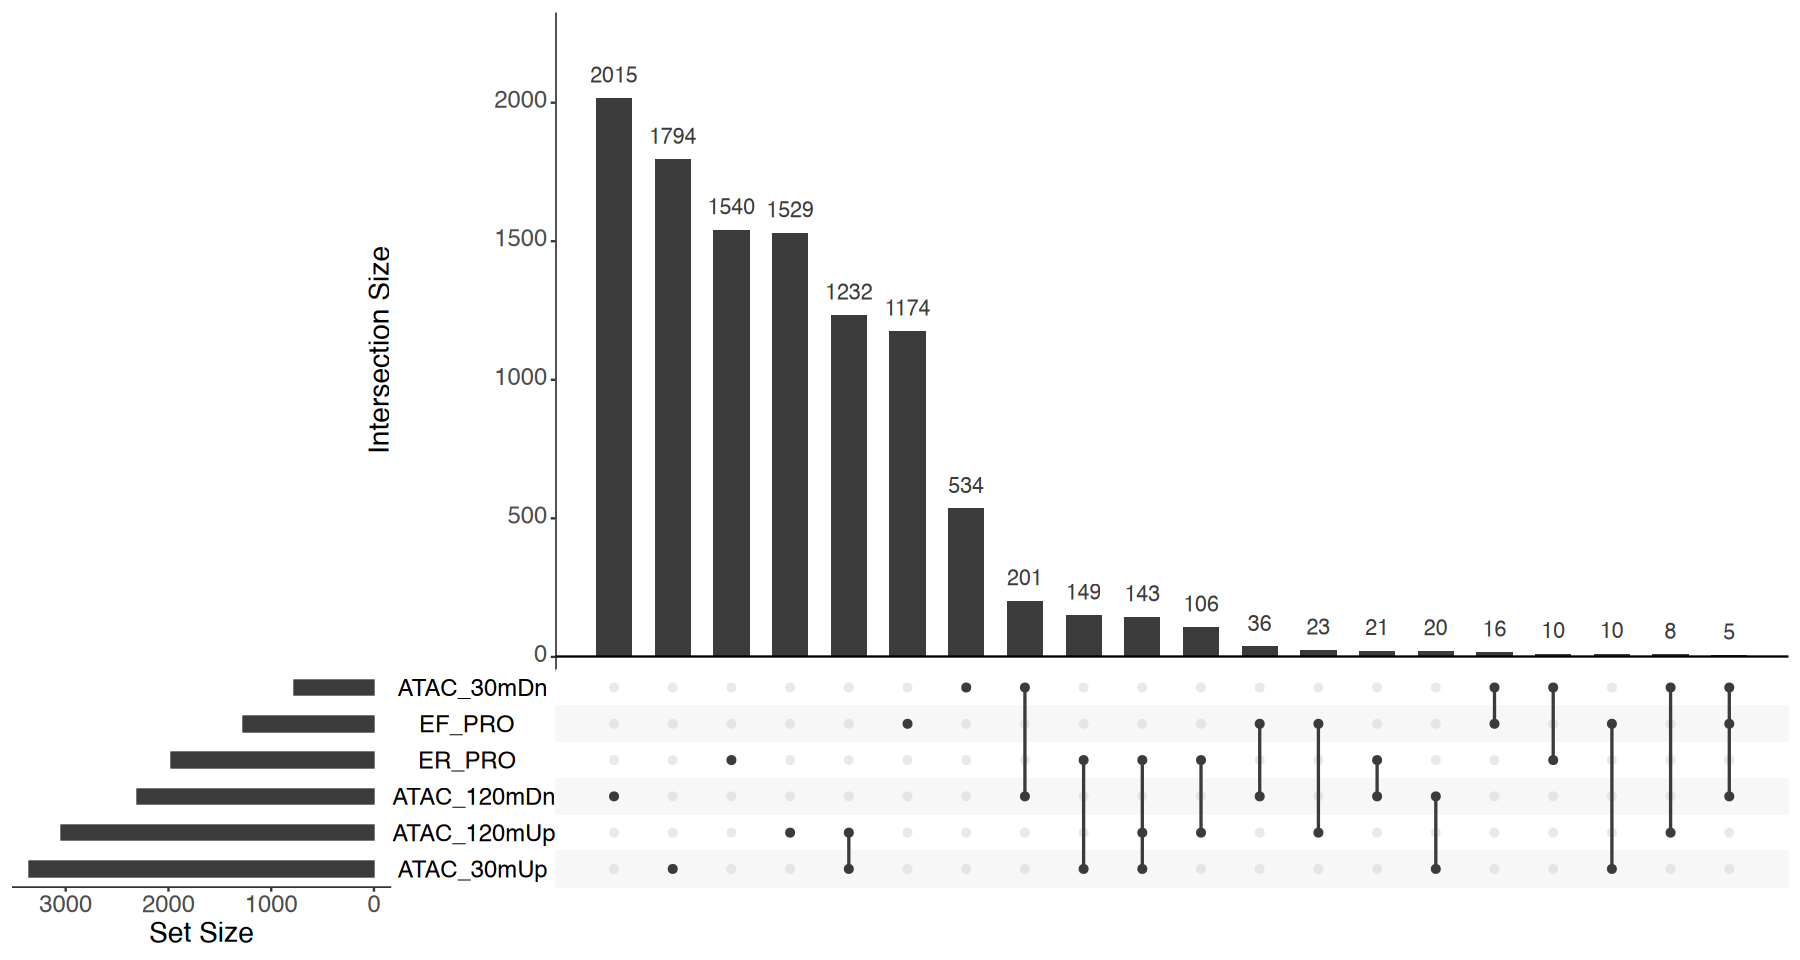

In [43]:
WSP_time <- list("ER_ATAC"=WSP_time_sig_atac$ER, "EF_ATAC"=WSP_time_sig_atac$EF, 
"EPR_ATAC"=WSP_time_sig_atac$EPR, "EPF_ATAC"=WSP_time_sig_atac$EPF, 
"LR_ATAC"=WSP_time_sig_atac$LR, "LF_ATAC"=WSP_time_sig_atac$LF, 
"ER_PRO"=WSP_time_sig_nontss$ER, "EF_PRO"=WSP_time_sig_nontss$EF, 
"EPR_PRO"=WSP_time_sig_nontss$EPR, "EPF_PRO"=WSP_time_sig_nontss$EPF, 
"LR_PRO"=WSP_time_sig_nontss$LR, "LF_PRO"=WSP_time_sig_nontss$LF)
library(UpSetR)
options(repr.plot.width=15, repr.plot.height=8)
upset(fromList(WSP_time), text.scale=2, nsets=12, order.by="freq", keep.order=TRUE, nintersects=20)

WSP_time <- list("ER_ATAC"=WSP_time_sig_atac$ER, "EF_ATAC"=WSP_time_sig_atac$EF, 
"EPR_ATAC"=WSP_time_sig_atac$EPR, "EPF_ATAC"=WSP_time_sig_atac$EPF, 
"LR_ATAC"=WSP_time_sig_atac$LR, "LF_ATAC"=WSP_time_sig_atac$LF, 
"ER_PRO"=WSP_time_sig_nontss$ER, "EF_PRO"=WSP_time_sig_nontss$EF)
library(UpSetR)
options(repr.plot.width=15, repr.plot.height=8)
upset(fromList(WSP_time), text.scale=2, nsets=8, order.by="freq", keep.order=TRUE, nintersects=20)

WSP_time <- list("ATAC_30mUp"=WSP_sig_atac$P30_vs_Veh_up, "ATAC_120mUp"=WSP_sig_atac$P120_vs_Veh_up, 
"ATAC_30mDn"=WSP_sig_atac$P30_vs_Veh_down, "ATAC_120mDn"=WSP_sig_atac$P120_vs_Veh_down, 
"ER_PRO"=WSP_time_sig_nontss$ER, "EF_PRO"=WSP_time_sig_nontss$EF)
library(UpSetR)
options(repr.plot.width=15, repr.plot.height=8)
upset(fromList(WSP_time), text.scale=2, nsets=6, order.by="freq", keep.order=TRUE, nintersects=20)

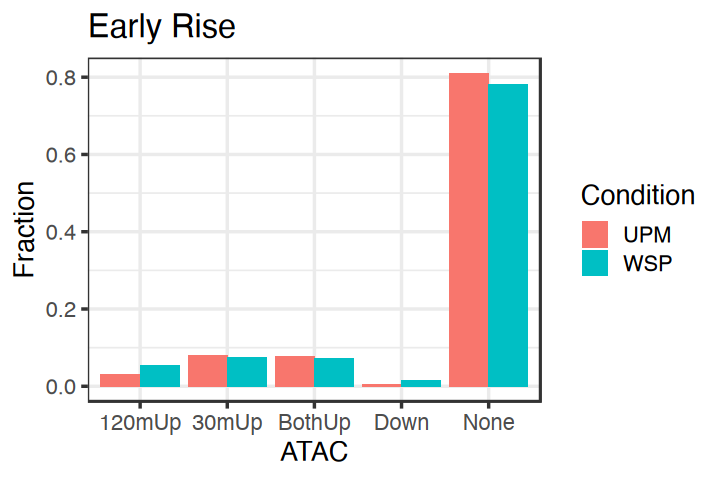

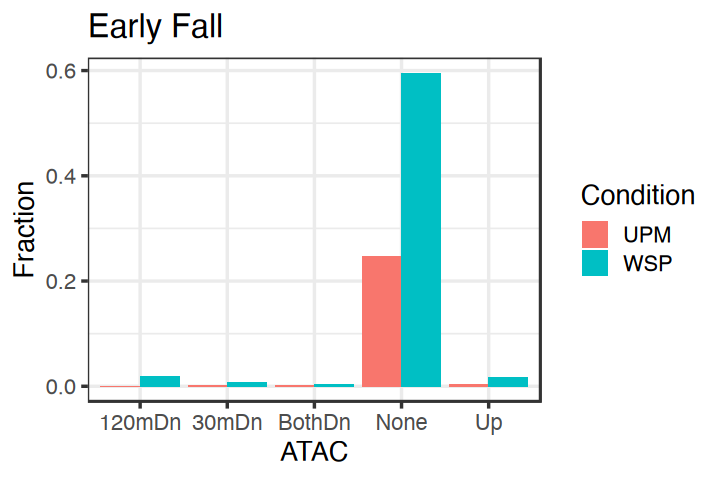

In [52]:
ER_plot_df = data.table("Number"=c(2666, 266, 100, 253, 11, 1540, 149, 106, 143, 31),
"N"=c(rep(length(UPM_time_sig_nontss$ER), 5), rep(length(WSP_time_sig_nontss$ER), 5)),
"ATAC"=c("None", "30mUp", "120mUp", "BothUp", "Down", "None", "30mUp", "120mUp", "BothUp", "Down"), 
"Condition"=c(rep("UPM", 5), rep("WSP", 5)))

ER_plot_df$Fraction <- ER_plot_df$Number/ER_plot_df$N
#ER_plot_df
options(repr.plot.width=6, repr.plot.height=4)
library(ggplot2)
ggplot(ER_plot_df, aes(x=ATAC, y=Fraction, fill=Condition)) + geom_bar(stat="identity", position="dodge") + 
theme_bw(base_size=16) + 
ggtitle("Early Rise")

EF_plot_df = data.table("Number"=c(812, 7, 0, 3, 9, 1174, 16, 36, 5, 33),
"N"=c(rep(length(UPM_time_sig_nontss$EF), 5), rep(length(WSP_time_sig_nontss$EF), 5)),
"ATAC"=c("None", "30mDn", "120mDn", "BothDn", "Up", "None", "30mDn", "120mDn", "BothDn", "Up"), 
"Condition"=c(rep("UPM", 5), rep("WSP", 5)))


EF_plot_df$Fraction <- EF_plot_df$Number/ER_plot_df$N
#ER_plot_df
options(repr.plot.width=6, repr.plot.height=4)
library(ggplot2)
ggplot(EF_plot_df, aes(x=ATAC, y=Fraction, fill=Condition)) + geom_bar(stat="identity", position="dodge") + 
theme_bw(base_size=16) + 
ggtitle("Early Fall")

Most of the early rise/fall pro do not do anything in ATAC. 
* Early Rise
	* 125 EPR ATAC, 60 ER ATAC, 32 LR ATAC
* Early Fall
	* 11 LR ATAC, 11 LF ATAC, 7 EF ATAC

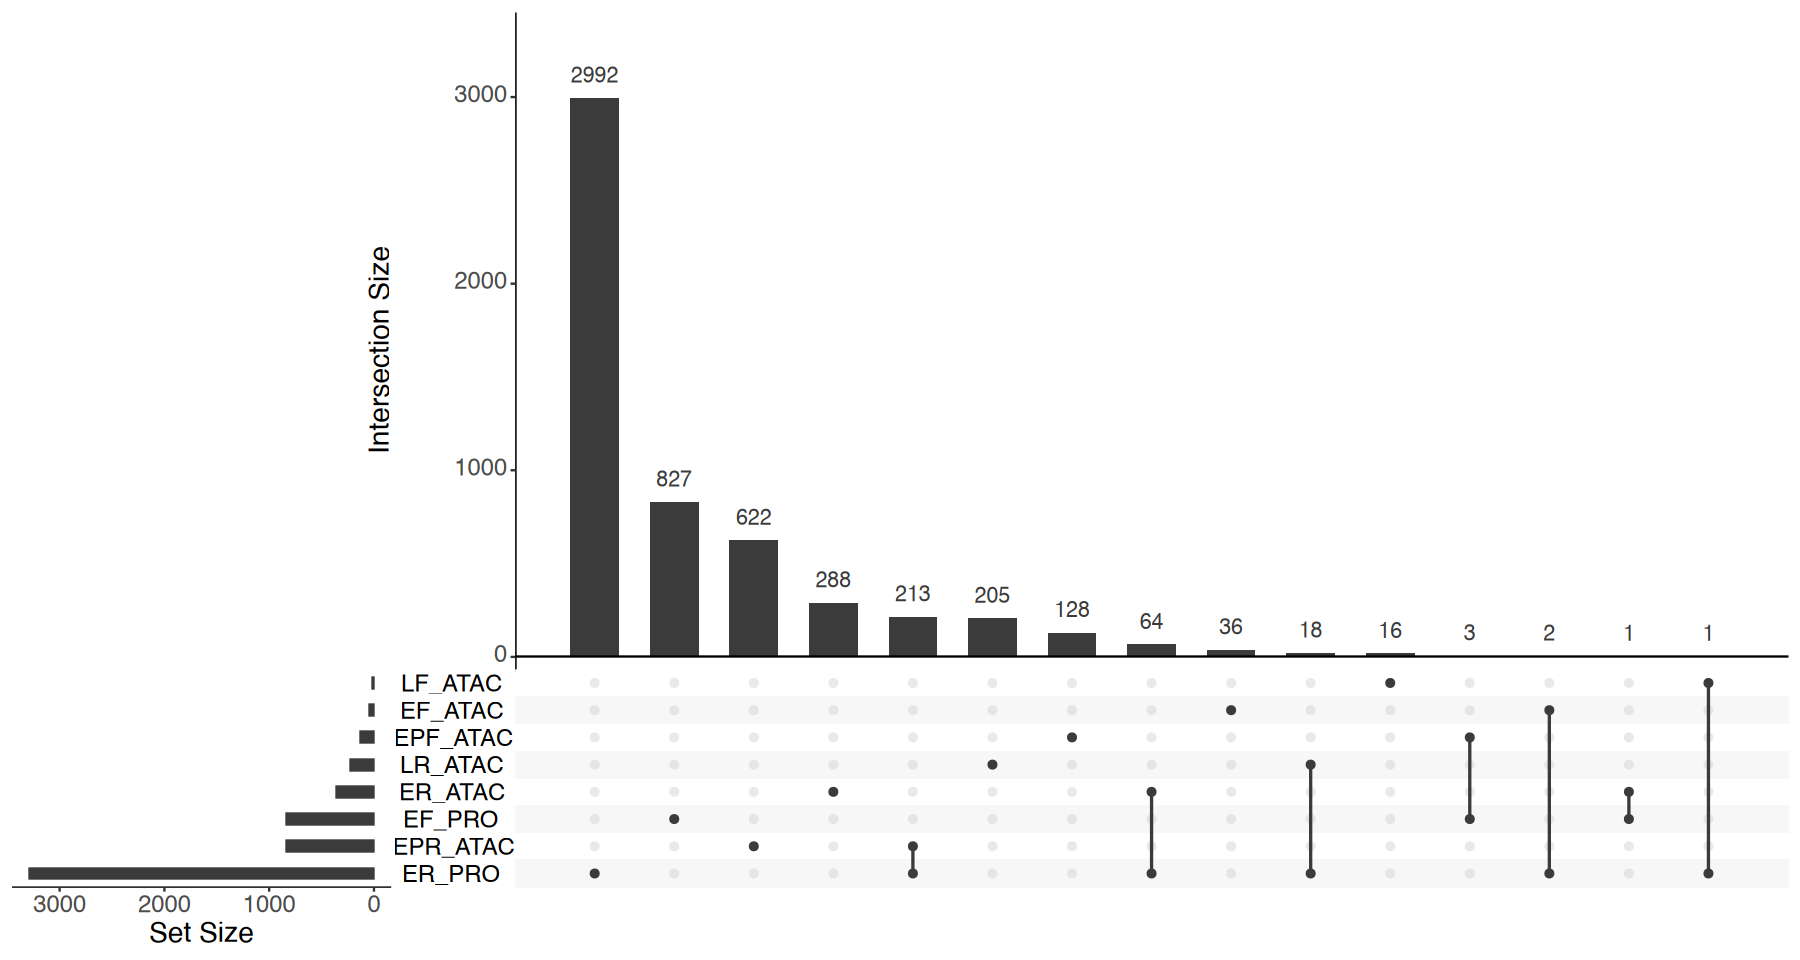

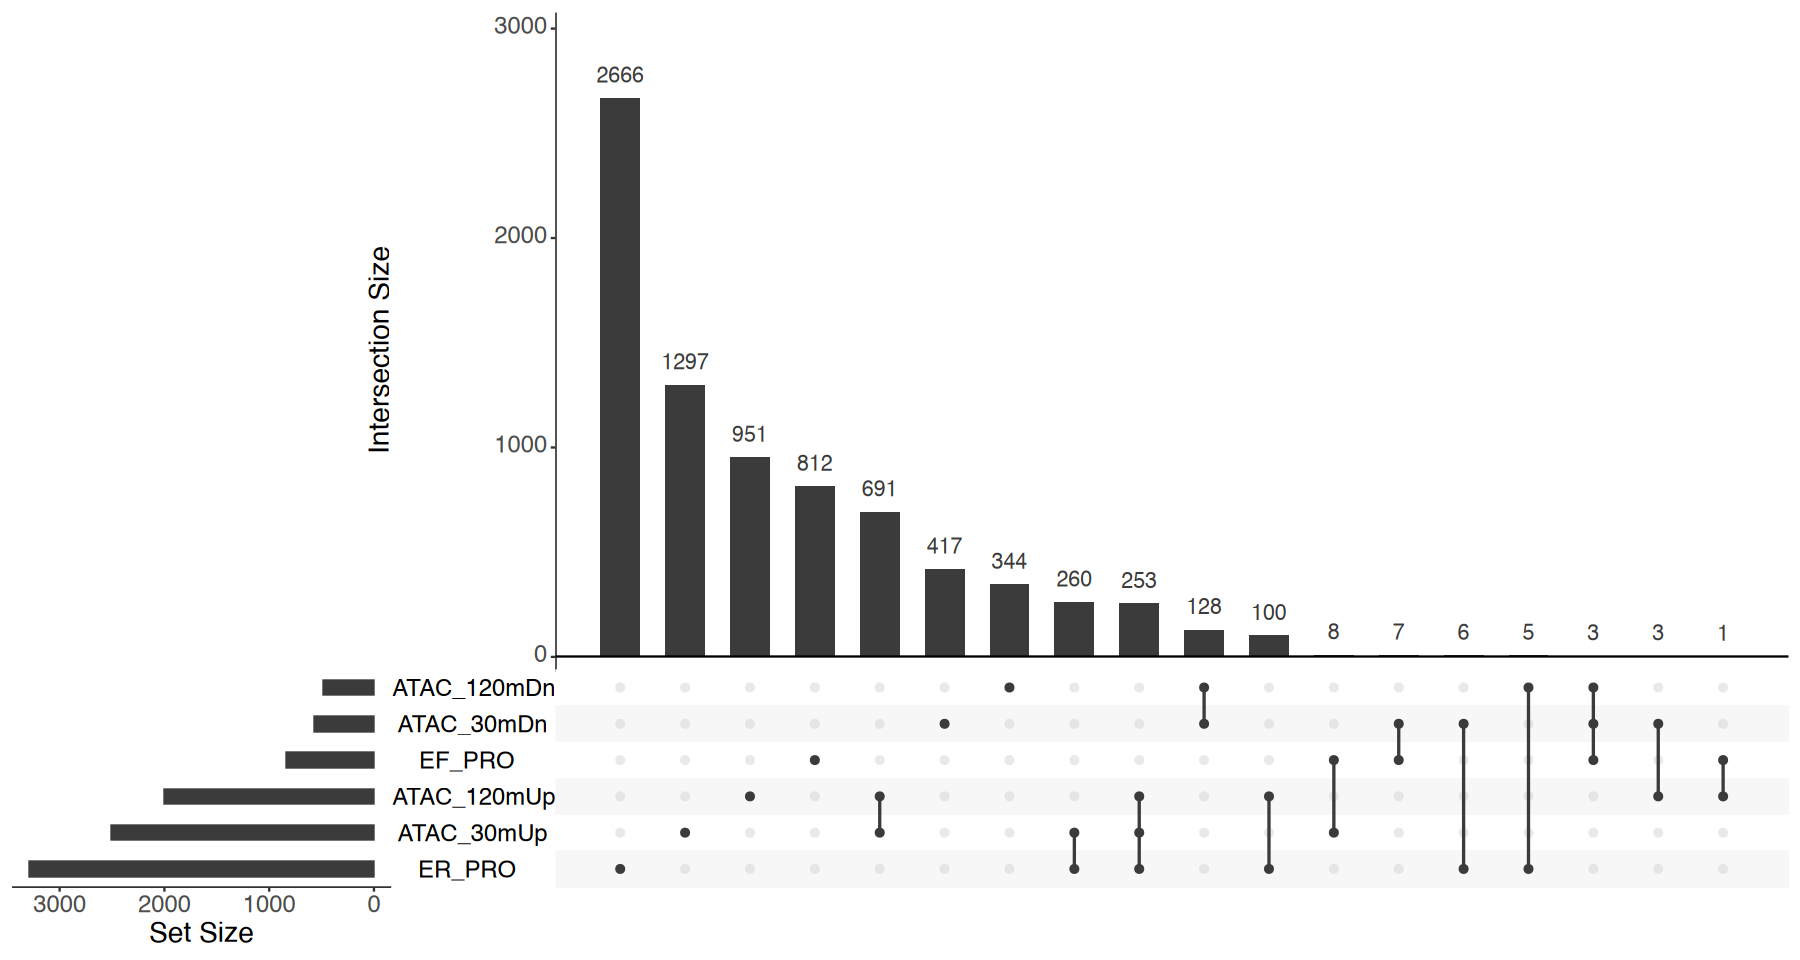

In [51]:
UPM_time <- list("ER_ATAC"=UPM_time_sig_atac$ER, "EF_ATAC"=UPM_time_sig_atac$EF, 
"EPR_ATAC"=UPM_time_sig_atac$EPR, "EPF_ATAC"=UPM_time_sig_atac$EPF, 
"LR_ATAC"=UPM_time_sig_atac$LR, "LF_ATAC"=UPM_time_sig_atac$LF, 
"ER_PRO"=UPM_time_sig_nontss$ER, "EF_PRO"=UPM_time_sig_nontss$EF)
library(UpSetR)
options(repr.plot.width=15, repr.plot.height=8)
upset(fromList(UPM_time), text.scale=2, nsets=8, order.by="freq", keep.order=TRUE, nintersects=20)

UPM_time <- list("ATAC_30mUp"=UPM_sig_atac$P30_vs_Veh_up, "ATAC_120mUp"=UPM_sig_atac$P120_vs_Veh_up, 
"ATAC_30mDn"=UPM_sig_atac$P30_vs_Veh_down, "ATAC_120mDn"=UPM_sig_atac$P120_vs_Veh_down, 
"ER_PRO"=UPM_time_sig_nontss$ER, "EF_PRO"=UPM_time_sig_nontss$EF)
library(UpSetR)
options(repr.plot.width=15, repr.plot.height=8)
upset(fromList(UPM_time), text.scale=2, nsets=6, order.by="freq", keep.order=TRUE, nintersects=30)

[1] 3290

* Early Rise:
	* 213 EPR ATAC, 64 ER ATAC, 18 LR ATAC
	* 260 30min up, 253 30+120min up, 100 120min up; 6 30m Dn, 5 120m Dn
* Early Fall:
	* 8 30m up, 7 30m down, 3 all down

## What does the ER/F in PRO look like in ATAC

In [26]:
# what sig in ATAC and PRO
upm_atac_pro_sig = intersect(unlist(UPM_sig_nontss), unlist(UPM_sig_atac))
length(upm_atac_pro_sig)
wsp_atac_pro_sig = intersect(unlist(WSP_sig_nontss), unlist(WSP_sig_atac))
length(wsp_atac_pro_sig)

[1] 2297

[1] 1869

[1] 3290

[1] 2297    9

[1] 2270    9

The automatically generated colors map from the minus and plus 99^th of
the absolute values in the matrix. There are outliers in the matrix
whose patterns might be hidden by this color mapping. You can manually
set the color to `col` argument.

Use `suppressMessages()` to turn off this message.



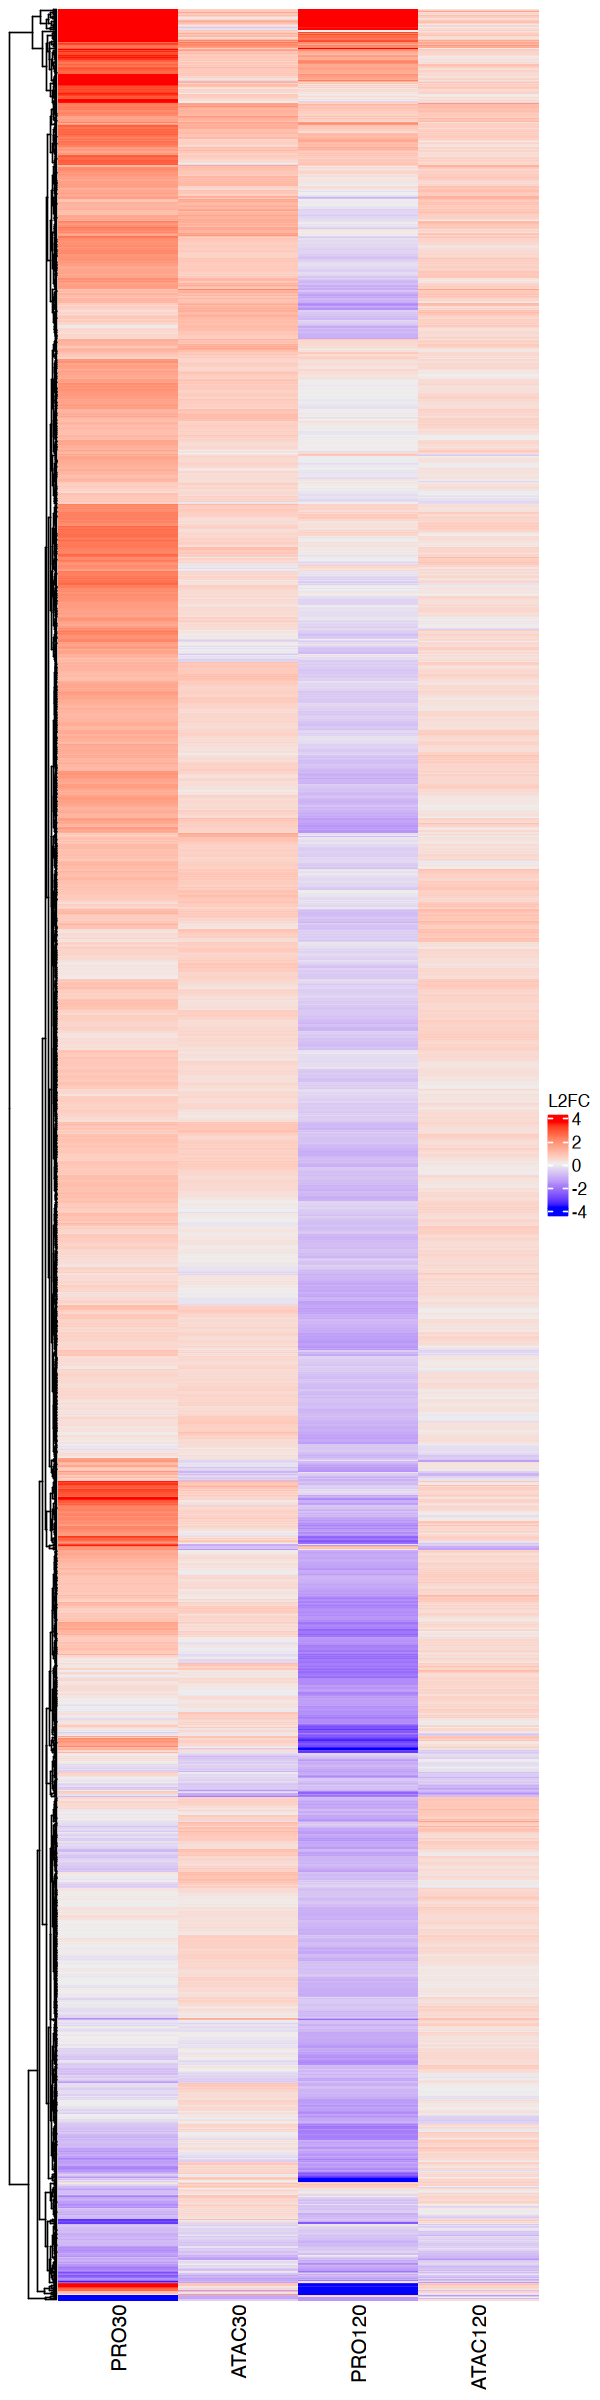

In [35]:
# plot the directions
options(repr.plot.width=5, repr.plot.height=20)
UPM_filt_df = UPM_df[UPM_df$Enhancer %in% upm_atac_pro_sig,]
dim(UPM_filt_df)
dim(UPM_filt_df[complete.cases(UPM_filt_df),])
Heatmap(as.matrix(UPM_filt_df[,c("PRO30", "ATAC30", "PRO120", "ATAC120")]), 
name="L2FC", show_row_names=FALSE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)


[1] 1869    9

[1] 1838    9

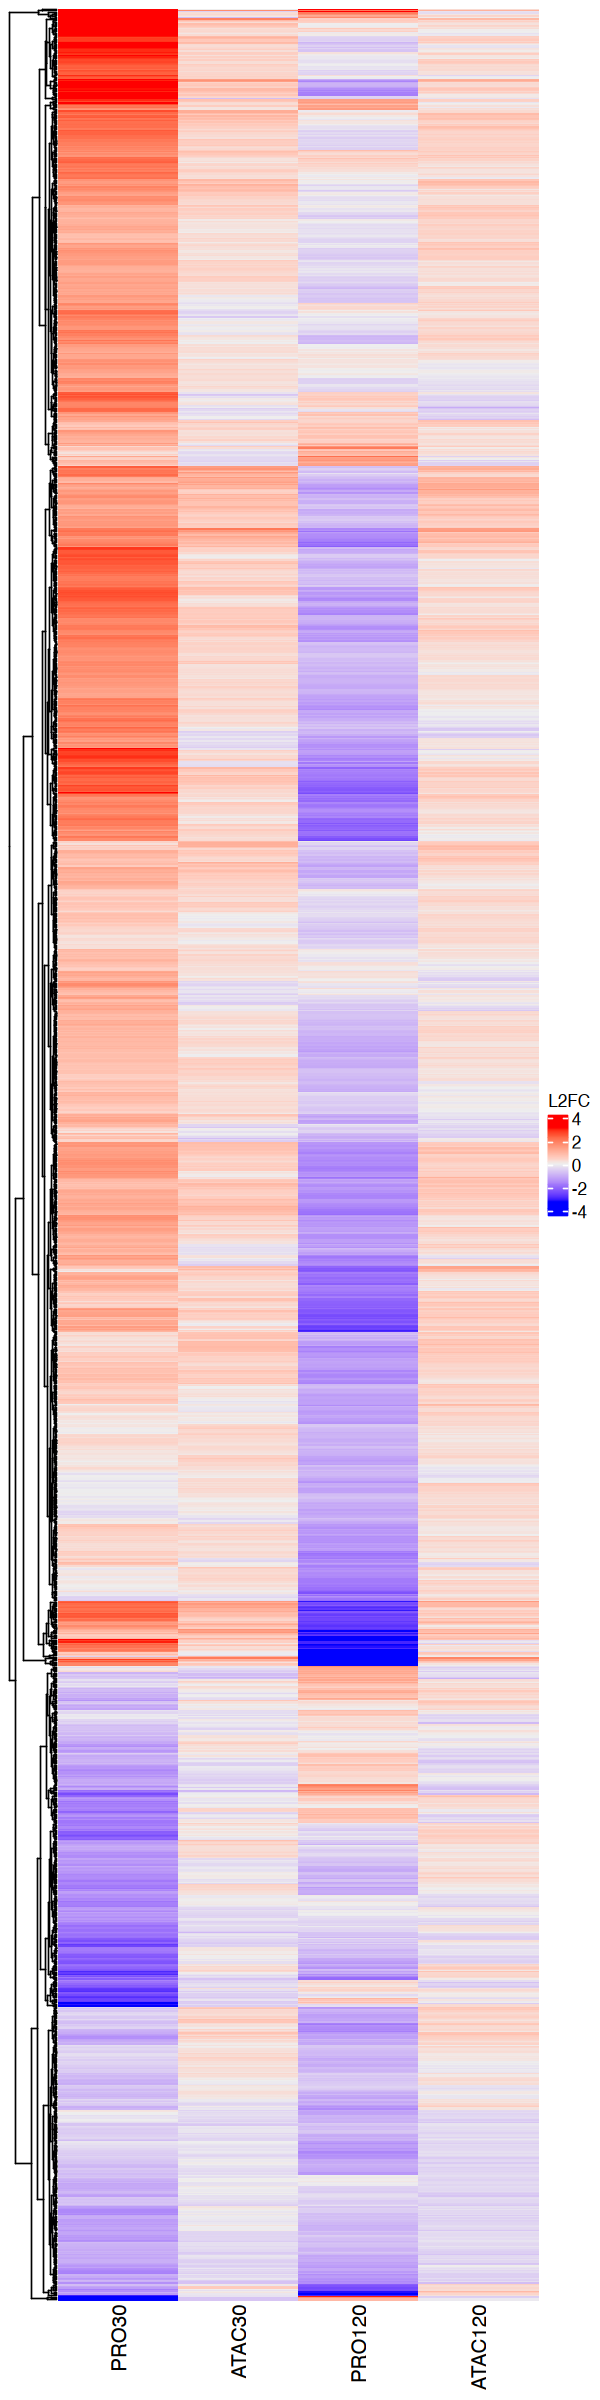

In [36]:
# plot the directions
options(repr.plot.width=5, repr.plot.height=20)
WSP_filt_df = WSP_df[WSP_df$Enhancer %in% wsp_atac_pro_sig,]
dim(WSP_filt_df)
dim(WSP_filt_df[complete.cases(WSP_filt_df),])
Heatmap(as.matrix(WSP_filt_df[,c("PRO30", "ATAC30", "PRO120", "ATAC120")]), 
name="L2FC", show_row_names=FALSE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)


[1] 3290

[1] 3290    9

[1] 2699    9

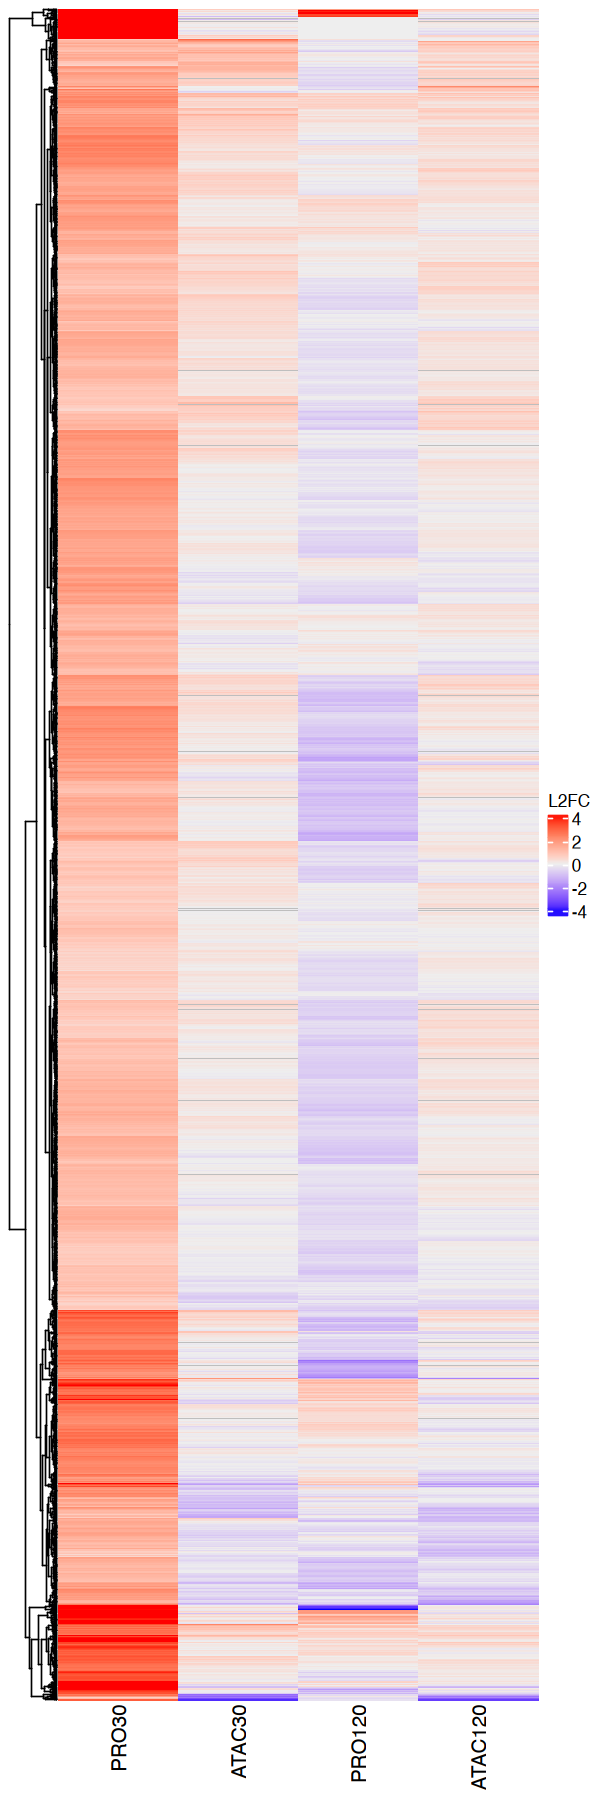

In [39]:
length(UPM_time_sig_nontss$ER)
# plot the directions
options(repr.plot.width=5, repr.plot.height=15)
UPM_filt_df = UPM_df[UPM_df$Enhancer %in% UPM_time_sig_nontss$ER,]
dim(UPM_filt_df)
dim(UPM_filt_df[complete.cases(UPM_filt_df),])
Heatmap(as.matrix(UPM_filt_df[,c("PRO30", "ATAC30", "PRO120", "ATAC120")]), 
name="L2FC", show_row_names=FALSE, show_column_names=TRUE, cluster_rows=TRUE, cluster_columns=FALSE)
